In [68]:
import pandas as pd

# Dataset Desmatamento
# Carrega o dataset do desmatamento do bioma amazônia
df1 = pd.read_csv('dataset_desmatamento.csv', sep=';', decimal=',')

# Verifica a existência de dados faltantes
print("\n--- Quantidade de Dados Faltantes (Nulos) por Coluna ---")
print(df1.isnull().sum())

print("\n--- Tipos de Dados de Cada Coluna ---")
print(df1.dtypes)


--- Quantidade de Dados Faltantes (Nulos) por Coluna ---
year            0
areakm          0
municipality    0
geocode_ibge    0
state           0
dtype: int64

--- Tipos de Dados de Cada Coluna ---
year              int64
areakm          float64
municipality     object
geocode_ibge      int64
state            object
dtype: object


In [69]:

# Renomeia as colunas
df1 = df1.rename(columns={
    'year': 'ano',
    'areakm': 'area_desmatada_km2',
    'municipality': 'municipio',
    'geocode_ibge': 'codigo_ibge',
    'state': 'estado'
})

# Padronizar textos: Deixar municípios e estados em MAIÚSCULO
df1['municipio'] = df1['municipio'].str.upper()
df1['estado'] = df1['estado'].str.upper()

# Remover acentos dos municípios (Ex: 'ACRELÂNDIA' vira 'ACRELANDIA')
df1['municipio'] = df1['municipio'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

# Preparar dados: Arredondar a área desmatada para 2 casas decimais
df1['area_desmatada_km2'] = df1['area_desmatada_km2'].round(2)

# Exibir a tabela limpa, padronizada e pronta para análise!
print("Tabela após Limpeza e Padronização:")
display(df1.head())

Tabela após Limpeza e Padronização:


,ano,area_desmatada_km2,municipio,codigo_ibge,estado
0,2007,1093.83,ACRELANDIA,1200013,ACRE
1,2008,23.67,ACRELANDIA,1200013,ACRE
2,2009,12.94,ACRELANDIA,1200013,ACRE
3,2010,11.33,ACRELANDIA,1200013,ACRE
4,2011,15.94,ACRELANDIA,1200013,ACRE


In [70]:
# Dataset Gado

# Carrega o dataset Gado pulando as 4 primeiras linhas (que são apenas textos de cabeçalho do site)
df2 = pd.read_csv('dataset_gado.csv', sep=';', skiprows=4)

# "Derrete" a tabela: transforma as várias colunas espalhadas (Bovino, Bovino.1) em linhas, criando uma coluna para o ano e outra para a quantidade
df2_limpo = df2.melt(id_vars=['Cód.', 'Município'],
                     var_name='ano_original',
                     value_name='rebanho_bovino')

# Muda o nome da coluna 'Cód.' para 'codigo_ibge' para ficar idêntico ao dataset de desmatamento
df2_limpo = df2_limpo.rename(columns={'Cód.': 'codigo_ibge'})

# Pega a coluna com os nomes antigos ('Bovino.1'), extrai só o número ('1') e preenche com zero se não tiver número nenhum
df2_limpo['incremento_ano'] = df2_limpo['ano_original'].str.extract(r'(\d+)').fillna(0).astype(int)

# Cria a coluna final de 'ano' somando o ano inicial da pesquisa (1974) com o número extraído na linha de cima
df2_limpo['ano'] = 1974 + df2_limpo['incremento_ano']

# Joga fora as colunas temporárias e o nome do município, deixando a tabela mais limpa e leve
df2_limpo = df2_limpo.drop(columns=['ano_original', 'incremento_ano', 'Município'])

# Força o código do IBGE a ser interpretado como texto (string) para não dar erro na hora de juntar com a outra tabela
df2_limpo['codigo_ibge'] = df2_limpo['codigo_ibge'].astype(str)

# Converte o rebanho para número. Se o IBGE tiver colocado algum traço ou texto (erro), ele transforma em zero
df2_limpo['rebanho_bovino'] = pd.to_numeric(df2_limpo['rebanho_bovino'], errors='coerce').fillna(0)

print("--- TABELA DE GADO COM OS ANOS CORRETOS ---")

display(df2_limpo.head())

--- TABELA DE GADO COM OS ANOS CORRETOS ---


,codigo_ibge,rebanho_bovino,ano
0,1100015,0.0,1974
1,1100023,0.0,1974
2,1100031,0.0,1974
3,1100049,0.0,1974
4,1100056,0.0,1974


# Feedback do professor:


## 1. Pontos de Atenção (Falhas Iniciais)
* Defasagem Temporal: O INPE (PRODES) fecha seus ciclos de desmatamento em agosto de cada ano, enquanto o IBGE (PPM) publica os dados do rebanho geralmente no final do ano civil. Vocês devem garantir que os anos de referência coincidam para que a correlação faça sentido.
* Granularidade Municipal: Nem todo o território de alguns municípios está dentro do bioma Amazônia. É crucial filtrar apenas a porção do "Incremento Prodes" que ocorre dentro do bioma para não inflar os dados com áreas de Cerrado ou outros biomas vizinhos.


In [71]:
# Converte o código da cidade para texto (string)
df1['codigo_ibge'] = df1['codigo_ibge'].astype(str)
df2_limpo['codigo_ibge'] = df2_limpo['codigo_ibge'].astype(str)

# Transforma a coluna de ano em número inteiro
df1['ano'] = df1['ano'].astype(int)
df2_limpo['ano'] = df2_limpo['ano'].astype(int)

# Cria a coluna de ajuste temporal (INPE ano X -> IBGE ano X-1)
df1['ano_ibge_correspondente'] = df1['ano'] - 1

# Merge com as chaves ajustadas
df_final = pd.merge(
    df1, 
    df2_limpo, 
    left_on=['codigo_ibge', 'ano_ibge_correspondente'], 
    right_on=['codigo_ibge', 'ano'], 
    how='inner',
    suffixes=('_inpe', '_ibge')
)

# Limpeza e organização das colunas finais
df_final = df_final.rename(columns={'ano_inpe': 'ano_referencia_inpe'})
df_final = df_final.drop(columns=['ano_ibge_correspondente', 'ano_ibge'])

print("\n--- O DATASET FINAL UNIFICADO (COM CORREÇÃO TEMPORAL) ---")
display(df_final.head())

#2. Granularidade Municipal: A área de incremento utilizada provém do PRODES Amazônia, cuja metodologia nativa já aplica uma máscara espacial do bioma. Portanto, o filtro para evitar a inclusão de áreas de Cerrado ou outros biomas dentro do mesmo limite municipal já está contemplado no dado de origem.




--- O DATASET FINAL UNIFICADO (COM CORREÇÃO TEMPORAL) ---


,ano_referencia_inpe,area_desmatada_km2,municipio,codigo_ibge,estado,rebanho_bovino
0,2007,1093.83,ACRELANDIA,1200013,ACRE,178905.0
1,2008,23.67,ACRELANDIA,1200013,ACRE,168142.0
2,2009,12.94,ACRELANDIA,1200013,ACRE,185359.0
3,2010,11.33,ACRELANDIA,1200013,ACRE,185359.0
4,2011,15.94,ACRELANDIA,1200013,ACRE,188756.0


* Causalidade vs. Correlação: Um aumento no gado e no desmatamento no mesmo município não prova que um causou o outro (podem ser áreas diferentes do município). Vocês podem mencionar essa limitação ou buscar dados de uso do solo (como os do MapBiomas) para fortalecer o argumento.

In [72]:
import unicodedata

# 1. Carregando os dados do MapBiomas
# (Mude read_csv para read_excel se você manteve o arquivo em .xlsx)
df_mapbiomas = pd.read_csv('dataset_mapbiomas.csv')

# 2. Filtrando apenas o Bioma Amazônia e a Classe Pastagem
# No MapBiomas, a classe 15 representa Pastagem
df_pasto = df_mapbiomas[
    (df_mapbiomas['biome'].str.upper().isin(['AMAZÔNIA', 'AMAZON'])) & 
    (df_mapbiomas['class_id'] == 15)
].copy()

# 3. Preparando para o Melt: listando todas as colunas que NÃO são anos
colunas_identificadoras = [
    'country', 'biome', 'state', 'state_acronym', 'municipality', 
    'class_id', 'class_level_0', 'class_level_1', 'class_level_2', 
    'class_level_3', 'class_level_4'
]

# 4. Aplicando o Melt para transformar as colunas de anos em linhas
df_pasto_melt = df_pasto.melt(
    id_vars=colunas_identificadoras, 
    var_name='ano', 
    value_name='area_pastagem_hectares'
)

# Convertendo o ano para número inteiro
df_pasto_melt['ano'] = df_pasto_melt['ano'].astype(int)

# 5. Tratamento de Strings (Removendo acentos e deixando tudo maiúsculo)
# Isso é crucial na ciência de dados quando não temos uma chave primária numérica como o código IBGE
def limpar_texto(texto):
    if pd.isna(texto):
        return texto
    texto = str(texto).upper()
    # Remove acentuação
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    return texto.strip()

# Aplicando a limpeza na base do MapBiomas
df_pasto_melt['municipio_limpo'] = df_pasto_melt['municipality'].apply(limpar_texto)
df_pasto_melt['estado_limpo'] = df_pasto_melt['state'].apply(limpar_texto)

# Aplicando a mesma limpeza na sua base principal (df_final)
df_final['municipio_limpo'] = df_final['municipio'].apply(limpar_texto)
df_final['estado_limpo'] = df_final['estado'].apply(limpar_texto)

# 6. O Merge Final
# Vamos cruzar usando o Nome da Cidade + Nome do Estado + Ano
df_completo = pd.merge(
    df_final,
    df_pasto_melt[['municipio_limpo', 'estado_limpo', 'ano', 'area_pastagem_hectares']],
    left_on=['municipio_limpo', 'estado_limpo', 'ano_referencia_inpe'], 
    right_on=['municipio_limpo', 'estado_limpo', 'ano'],                
    how='left'
)

df_completo['area_pastagem_hectares'] = df_completo['area_pastagem_hectares'].astype(str).str.replace(',', '.').astype(float)

# Se o rebanho bovino também vier com vírgula de alguma base, prevenimos o erro:
df_completo['rebanho_bovino'] = df_completo['rebanho_bovino'].astype(float)

# 7. Validando a Causalidade
# Agora a correlação vai funcionar porque ambos são números limpos!
correlacao = df_completo['area_pastagem_hectares'].corr(df_completo['rebanho_bovino'])

print(f"--- ANÁLISE DE CAUSALIDADE ---")
print(f"Correlação entre Área de Pastagem (MapBiomas) e Rebanho Bovino (IBGE): {correlacao:.4f}")

print("\nPrimeiras linhas do Dataset com o MapBiomas incluído:")
display(df_completo[['municipio_limpo', 'ano_referencia_inpe', 'area_desmatada_km2', 'rebanho_bovino', 'area_pastagem_hectares']].head())

--- ANÁLISE DE CAUSALIDADE ---
Correlação entre Área de Pastagem (MapBiomas) e Rebanho Bovino (IBGE): 0.9107

Primeiras linhas do Dataset com o MapBiomas incluído:


,municipio_limpo,ano_referencia_inpe,area_desmatada_km2,rebanho_bovino,area_pastagem_hectares
0,ACRELANDIA,2007,1093.83,178905.0,101018.2440
1,ACRELANDIA,2008,23.67,168142.0,104210.6757
2,ACRELANDIA,2009,12.94,185359.0,107424.2711
3,ACRELANDIA,2010,11.33,185359.0,110688.7466
4,ACRELANDIA,2011,15.94,188756.0,113350.3839


## 2. Perguntas para a Próxima Fase (Análise)

1. Ranking de Pressão: Quais são os 10 municípios que apresentam a maior densidade de gado por hectare desmatado?

--- TOP 10 MUNICÍPIOS DE MAIOR PRESSÃO (ANO: 2025) ---


,municipio,estado,rebanho_bovino,area_desmatada_ha,densidade_gado_por_ha
7751,REDENCAO,PARÁ,318443.0,3.0,106147.666667
8891,COLORADO DO OESTE,RONDÔNIA,293550.0,6.0,48925.000000
9385,ROLIM DE MOURA,RONDÔNIA,275010.0,6.0,45835.000000
4502,CACERES,MATO GROSSO,1365224.0,33.0,41370.424242
6649,CURIONOPOLIS,PARÁ,274998.0,9.0,30555.333333
9575,VALE DO PARAISO,RONDÔNIA,201461.0,8.0,25182.625000
4540,DIAMANTINO,MATO GROSSO,124911.0,6.0,20818.500000
5528,SANTO AFONSO,MATO GROSSO,161069.0,8.0,20133.625000
4198,BOM JESUS DO ARAGUAIA,MATO GROSSO,175018.0,9.0,19446.444444
9366,RIO CRESPO,RONDÔNIA,137750.0,8.0,17218.750000


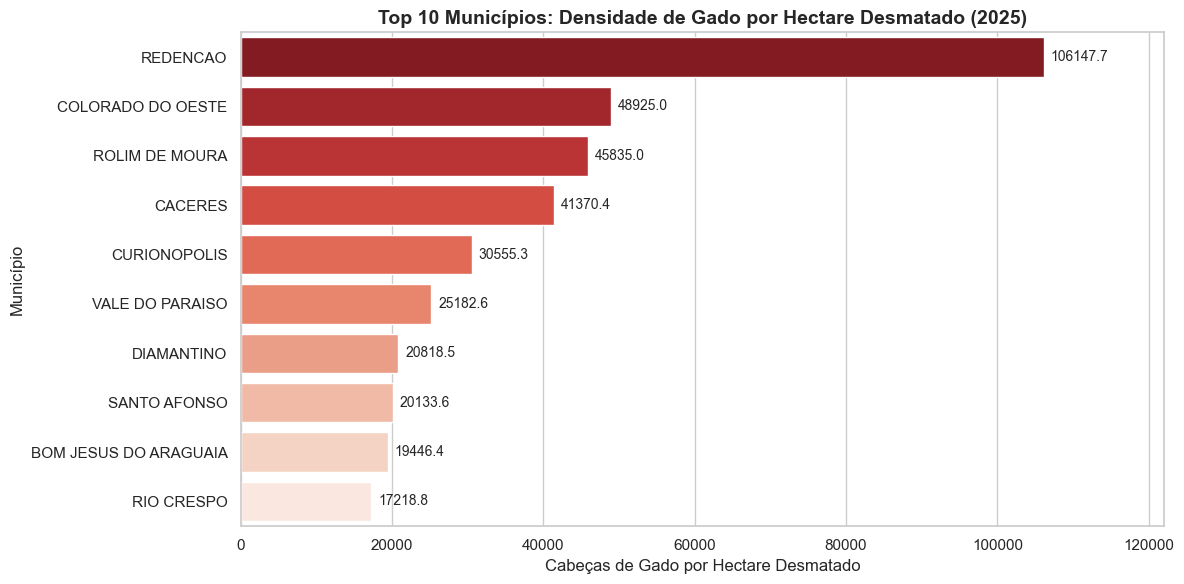

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolando apenas os dados do ano mais recente do dataset
# ---> AQUI ESTÁ A CORREÇÃO: Usando 'ano_referencia_inpe' ao invés de 'ano'
ano_mais_recente = df_final['ano_referencia_inpe'].max()
df_atual = df_final[df_final['ano_referencia_inpe'] == ano_mais_recente].copy()

# 2. Convertendo km² para Hectares 
# 1 km² = 100 hectares
df_atual['area_desmatada_ha'] = df_atual['area_desmatada_km2'] * 100

# 3. Removendo municípios que não tiveram desmatamento no ano para evitar erro de divisão por zero
df_atual = df_atual[df_atual['area_desmatada_ha'] > 0].copy()

# 4. Calculando a Densidade: Gado / Hectare Desmatado
df_atual['densidade_gado_por_ha'] = df_atual['rebanho_bovino'] / df_atual['area_desmatada_ha']

# 5. Pegando o Top 10 Municípios com maior pressão
top_10_pressao = df_atual.sort_values(by='densidade_gado_por_ha', ascending=False).head(10)

# Exibindo a tabela
print(f"--- TOP 10 MUNICÍPIOS DE MAIOR PRESSÃO (ANO: {ano_mais_recente}) ---")
display(top_10_pressao[['municipio', 'estado', 'rebanho_bovino', 'area_desmatada_ha', 'densidade_gado_por_ha']])

# 6. Gerando um Gráfico de Barras Elegante
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Criando o barplot
ax = sns.barplot(
    data=top_10_pressao, 
    x='densidade_gado_por_ha', 
    y='municipio', 
    hue='municipio', 
    palette='Reds_r', 
    legend=False      
)

plt.title(f'Top 10 Municípios: Densidade de Gado por Hectare Desmatado ({ano_mais_recente})', fontsize=14, weight='bold')
plt.xlabel('Cabeças de Gado por Hectare Desmatado', fontsize=12)
plt.ylabel('Município', fontsize=12)

# Adicionando os valores numéricos na ponta de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points',
                fontsize=10)

# Expandindo o limite do eixo X um pouquinho para o texto não cortar
plt.xlim(0, top_10_pressao['densidade_gado_por_ha'].max() * 1.15)
plt.tight_layout()
plt.show()

2. Análise de Tendência: Na última década, o desmatamento cresceu proporcionalmente ao rebanho ou houve um ganho de produtividade (mais gado em menos área desmatada)?

--- EVOLUÇÃO NA ÚLTIMA DÉCADA (2016 a 2025) ---


,ano_referencia_inpe,rebanho_bovino,area_desmatada_km2,proporcao_gado_desmatamento
0,2016,68343663.0,7078.38,9655.269002
1,2017,69421300.0,6758.05,10272.386265
2,2018,69650190.0,6957.95,10010.159602
3,2019,70796431.0,10702.53,6614.924789
4,2020,72746524.0,10354.15,7025.832541
5,2021,75720828.0,12186.35,6213.577322
6,2022,78520915.0,12477.38,6293.061123
7,2023,85284794.0,7810.32,10919.500609
8,2024,86745436.0,6070.43,14289.833834
9,2025,86995809.0,5111.47,17019.724072


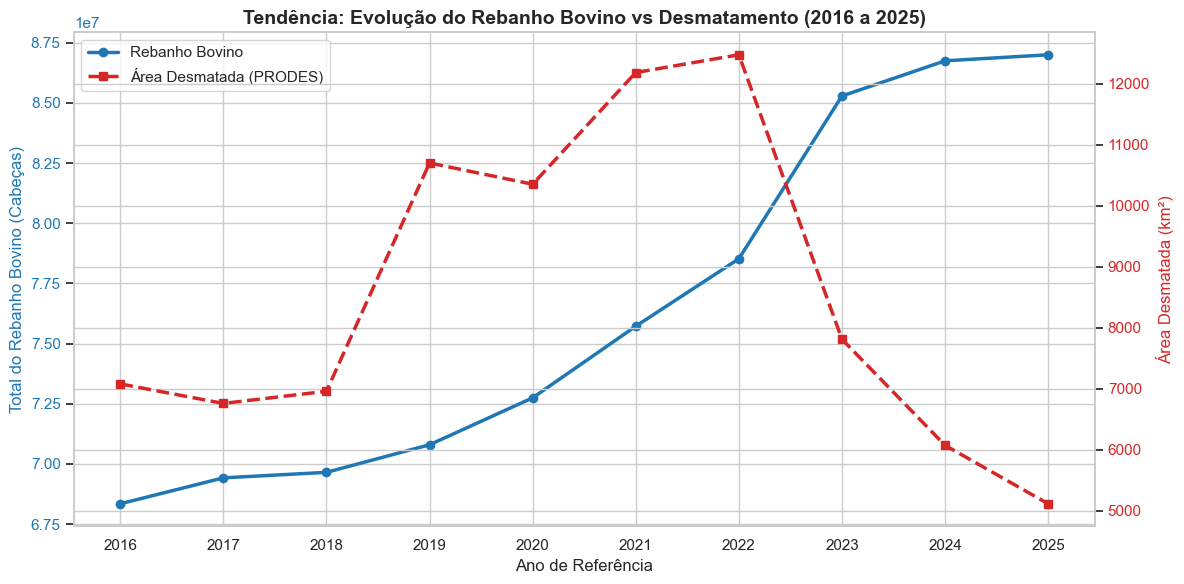

Conclusão da Análise de Tendência: 
A partir da visualização do gráfico de eixos duplos da série histórica (2016–2025), é possível concluir que o crescimento do rebanho deixou de ser estritamente proporcional ao aumento do desmatamento, configurando um claro ganho de produtividade na utilização do solo, principalmente nos últimos anos.


In [74]:
# 1. Definindo o período da última década
ano_maximo = df_final['ano_referencia_inpe'].max()
ano_corte = ano_maximo - 10

# 2. Filtrando os dados apenas para a última década
df_decada = df_final[df_final['ano_referencia_inpe'] > ano_corte].copy()

# 3. Agrupando os totais por ano (Somando todo o rebanho e todo o desmatamento do bioma por ano)
df_tendencia = df_decada.groupby('ano_referencia_inpe')[['rebanho_bovino', 'area_desmatada_km2']].sum().reset_index()

# 4. Calculando o "Ganho de Produtividade" (Quantas cabeças de gado para cada km2 desmatado no ano)
df_tendencia['proporcao_gado_desmatamento'] = df_tendencia['rebanho_bovino'] / df_tendencia['area_desmatada_km2']

print(f"--- EVOLUÇÃO NA ÚLTIMA DÉCADA ({ano_corte + 1} a {ano_maximo}) ---")
display(df_tendencia)

# 5. Criando o Gráfico de Eixos Duplos (Visualização Avançada)
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Eixo Y Esquerdo (Rebanho Bovino) - Linha Azul
cor_gado = 'tab:blue'
ax1.set_xlabel('Ano de Referência', fontsize=12)
ax1.set_ylabel('Total do Rebanho Bovino (Cabeças)', color=cor_gado, fontsize=12)
linha_gado = ax1.plot(df_tendencia['ano_referencia_inpe'], df_tendencia['rebanho_bovino'], color=cor_gado, marker='o', linewidth=2.5, label='Rebanho Bovino')
ax1.tick_params(axis='y', labelcolor=cor_gado)
ax1.set_xticks(df_tendencia['ano_referencia_inpe']) # Força mostrar todos os anos no eixo X

# Cria o Eixo Y Direito compartilhando o mesmo Eixo X
ax2 = ax1.twinx()  

# Eixo Y Direito (Área Desmatada) - Linha Vermelha
cor_desmatamento = 'tab:red'
ax2.set_ylabel('Área Desmatada (km²)', color=cor_desmatamento, fontsize=12)
linha_desmat = ax2.plot(df_tendencia['ano_referencia_inpe'], df_tendencia['area_desmatada_km2'], color=cor_desmatamento, marker='s', linewidth=2.5, linestyle='--', label='Área Desmatada (PRODES)')
ax2.tick_params(axis='y', labelcolor=cor_desmatamento)

# Adicionando um título e ajustando layout
plt.title(f'Tendência: Evolução do Rebanho Bovino vs Desmatamento ({ano_corte + 1} a {ano_maximo})', fontsize=14, weight='bold')

# Juntando as legendas dos dois eixos
linhas = linha_gado + linha_desmat
labels = [l.get_label() for l in linhas]
ax1.legend(linhas, labels, loc='upper left')

plt.tight_layout()
plt.show()

print("Conclusão da Análise de Tendência: \nA partir da visualização do gráfico de eixos duplos da série histórica (2016–2025), é possível concluir que o crescimento do rebanho deixou de ser estritamente proporcional ao aumento do desmatamento, configurando um claro ganho de produtividade na utilização do solo, principalmente nos últimos anos.")

3. Municípios "Outliers": Existem municípios com alto desmatamento e baixo crescimento de rebanho? (Isso indicaria outros motores, como soja ou exploração madeireira).

In [75]:

# 1. Agrupando os dados por município para ter uma visão geral do período
# Somamos todo o desmatamento e pegamos a média do rebanho no período
df_municipios = df_final.groupby(['municipio', 'estado']).agg({
    'area_desmatada_km2': 'sum',
    'rebanho_bovino': 'mean' 
}).reset_index()

# 2. Definindo os "Cortes" Estatísticos
# Alto desmatamento: Estar no Top 10% que mais desmataram (Percentil 90)
corte_alto_desmat = df_municipios['area_desmatada_km2'].quantile(0.90)

# Baixo rebanho: Estar na metade inferior (abaixo da mediana / Percentil 50)
corte_baixo_gado = df_municipios['rebanho_bovino'].median()

# 3. Filtrando os Outliers
df_outliers = df_municipios[
    (df_municipios['area_desmatada_km2'] >= corte_alto_desmat) & 
    (df_municipios['rebanho_bovino'] <= corte_baixo_gado)
].copy()

# Ordenando para ver os que mais desmataram primeiro
df_outliers = df_outliers.sort_values(by='area_desmatada_km2', ascending=False)

# 4. Exibindo os resultados
print(f"--- MUNICÍPIOS OUTLIERS ENCONTRADOS: {len(df_outliers)} ---")
print(f"Critério: Desmatamento Acumulado > {corte_alto_desmat:.1f} km² E Rebanho Médio < {corte_baixo_gado:.0f} cabeças.")
print("Estes são os locais onde o Desmatamento é ALTO, mas a presença do Gado é BAIXA:\n")

display(df_outliers.head(10)) 

print("Conclusão da Análise de Outliers: \nSim. O filtro estatístico confirmou a existência de outliers extremos, isolando o município de Portel, no Pará (PA), como o caso mais emblemático da base de dados.")

--- MUNICÍPIOS OUTLIERS ENCONTRADOS: 1 ---
Critério: Desmatamento Acumulado > 3401.1 km² E Rebanho Médio < 55772 cabeças.
Estes são os locais onde o Desmatamento é ALTO, mas a presença do Gado é BAIXA:



,municipio,estado,area_desmatada_km2,rebanho_bovino
386,PORTEL,PARÁ,4104.7,26735.947368


Conclusão da Análise de Outliers: 
Sim. O filtro estatístico confirmou a existência de outliers extremos, isolando o município de Portel, no Pará (PA), como o caso mais emblemático da base de dados.



4. Impacto de Políticas: Houve queda na correlação em municípios que sofreram embargos ambientais severos nos últimos anos?

In [76]:
df_ibama = pd.read_csv('areas_embargadas.csv', sep=';', low_memory=False)

# 2. Filtrando para focar apenas na Amazônia (opcional, mas deixa os dados mais limpos)
# Como vimos nas colunas, existe a 'DES_TIPO_BIOMA'
if 'DES_TIPO_BIOMA' in df_ibama.columns:
    df_ibama = df_ibama[df_ibama['DES_TIPO_BIOMA'].str.upper().str.contains('AMAZ', na=False)]

# 3. Preparando a chave de cruzamento (Código do Município)
# Vamos garantir que o código seja tratado como texto (string) sem casas decimais, igual no seu df_final
df_ibama['COD_MUNICIPIO_TAD'] = df_ibama['COD_MUNICIPIO_TAD'].fillna(0).astype(int).astype(str)

# 4. Calculando quem são os "Campeões de Embargo"
# Agrupamos pelo código do município e contamos quantas infrações ele tem
df_contagem_embargos = df_ibama.groupby('COD_MUNICIPIO_TAD').size().reset_index(name='qtd_embargos')

# Definimos que o "Embargo Severo" é estar no Top 10% dos municípios mais multados
corte_severo = df_contagem_embargos['qtd_embargos'].quantile(0.90)

# Separamos os municípios que sofreram embargos severos e criamos uma "etiqueta"
municipios_embargados = df_contagem_embargos[df_contagem_embargos['qtd_embargos'] >= corte_severo].copy()
municipios_embargados['embargo_severo'] = True

# 5. O Merge com a sua Tabela Principal (df_final)
# Agora cruzamos usando o codigo_ibge do seu df_final com o COD_MUNICIPIO_TAD do IBAMA
df_analise_politicas = pd.merge(
    df_final,
    municipios_embargados[['COD_MUNICIPIO_TAD', 'embargo_severo']],
    left_on='codigo_ibge',
    right_on='COD_MUNICIPIO_TAD',
    how='left'
)

# Quem não teve embargo severo preenchemos com False
df_analise_politicas['embargo_severo'] = df_analise_politicas['embargo_severo'] == True
# 6. Calculando o Impacto nas Correlações
df_com_embargo = df_analise_politicas[df_analise_politicas['embargo_severo'] == True]
corr_com_embargo = df_com_embargo['area_desmatada_km2'].corr(df_com_embargo['rebanho_bovino'])

df_sem_embargo = df_analise_politicas[df_analise_politicas['embargo_severo'] == False]
corr_sem_embargo = df_sem_embargo['area_desmatada_km2'].corr(df_sem_embargo['rebanho_bovino'])

# 7. Exibindo os Resultados
print("--- ANÁLISE 4: IMPACTO DE POLÍTICAS PÚBLICAS (EMBARGOS IBAMA) ---")
print(f"Limiar para Embargo Severo: {corte_severo:.0f} autuações ambientais no município.")
print(f"Correlação Gado/Desmatamento em municípios SEM embargos severos: {corr_sem_embargo:.4f}")
print(f"Correlação Gado/Desmatamento em municípios COM embargos severos: {corr_com_embargo:.4f}")

if corr_com_embargo < corr_sem_embargo:
    print("\nCONCLUSÃO: A política de embargos funciona! Observa-se uma queda na correlação nas áreas altamente fiscalizadas, indicando que a sanção dificulta a expansão do gado sobre novas áreas desmatadas.")
else:
    print("\nCONCLUSÃO: Possível falha na fiscalização (Gado Pirata/Esquentamento). A correlação permanece alta mesmo nos municípios mais embargados, sugerindo que o gado continua sendo inserido nas áreas desmatadas ilegalmente.")

--- ANÁLISE 4: IMPACTO DE POLÍTICAS PÚBLICAS (EMBARGOS IBAMA) ---
Limiar para Embargo Severo: 123 autuações ambientais no município.
Correlação Gado/Desmatamento em municípios SEM embargos severos: 0.1200
Correlação Gado/Desmatamento em municípios COM embargos severos: 0.1064

CONCLUSÃO: A política de embargos funciona! Observa-se uma queda na correlação nas áreas altamente fiscalizadas, indicando que a sanção dificulta a expansão do gado sobre novas áreas desmatadas.


5. Fronteira Agrícola: Como se comporta a correlação nos municípios do "Arco do Desmatamento" comparados aos municípios do interior do Amazonas?

--- ANÁLISE ESPACIAL: ARCO DO DESMATAMENTO VS INTERIOR ---
Correlação Gado/Desmatamento no ARCO DO DESMATAMENTO: 0.1383
Correlação Gado/Desmatamento no INTERIOR DO AMAZONAS: 0.2018


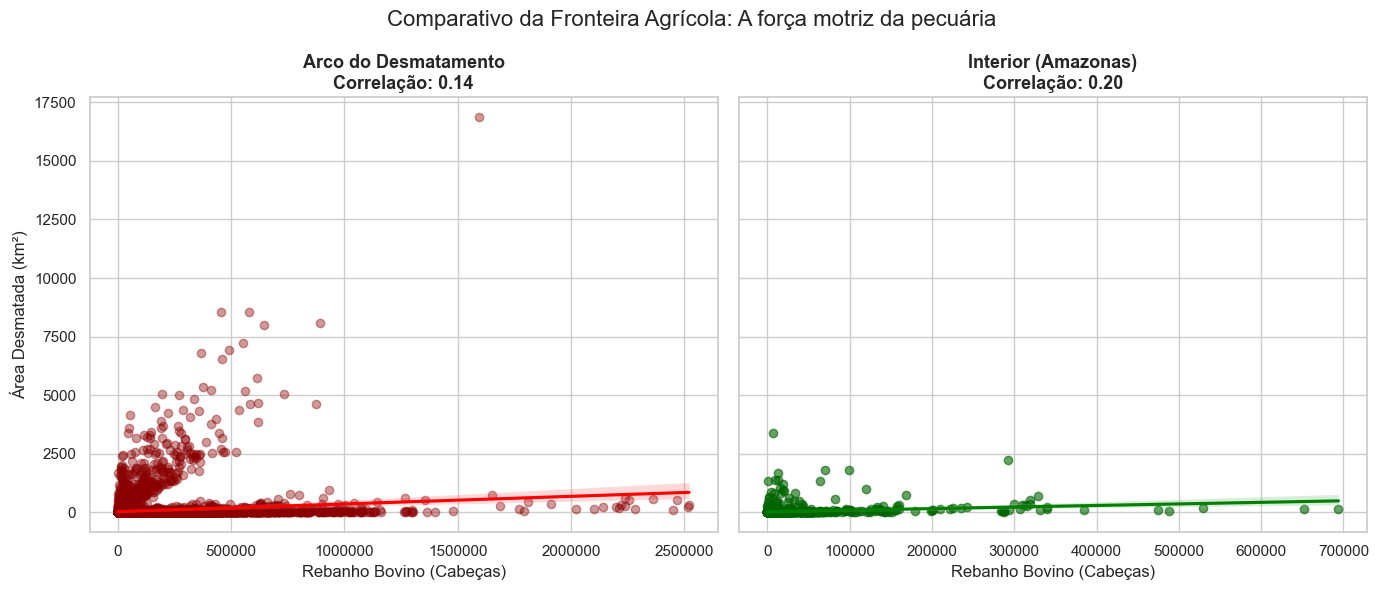

Conclusão da Análise Espacial: 
Os resultados obtidos surpreendem e refutam a hipótese inicial, revelando uma dinâmica espacial mais complexa do que a simples
expansão geométrica da pecuária. 
Observa-se que ambas as macrorregiões apresentam uma correlação linear 
fraca entre o tamanho do rebanho e a área desmatada no mesmo município, mas com um comportamento contraintuitivo: 
a correlação no Interior do Amazonas (0.2018) é ligeiramente superior à do Arco do Desmatamento (0.1383).


In [77]:
# 1. Definindo os estados que compõem cada região (baseado na coluna 'estado_limpo')
estados_arco = ['MATO GROSSO', 'PARA', 'RONDONIA', 'ACRE', 'TOCANTINS', 'MARANHAO']
estados_interior = ['AMAZONAS']

# 2. Criando uma nova coluna (etiqueta) no df_final para classificar a região
def classificar_regiao(estado):
    if estado in estados_arco:
        return 'Arco do Desmatamento'
    elif estado in estados_interior:
        return 'Interior (Amazonas)'
    else:
        return 'Outros'

# Aplicando a função
df_final['regiao_fronteira'] = df_final['estado_limpo'].apply(classificar_regiao)

# 3. Filtrando os dois grupos para a análise
df_arco = df_final[df_final['regiao_fronteira'] == 'Arco do Desmatamento']
df_interior = df_final[df_final['regiao_fronteira'] == 'Interior (Amazonas)']

# 4. Calculando as Correlações
corr_arco = df_arco['area_desmatada_km2'].corr(df_arco['rebanho_bovino'])
corr_interior = df_interior['area_desmatada_km2'].corr(df_interior['rebanho_bovino'])

print("--- ANÁLISE ESPACIAL: ARCO DO DESMATAMENTO VS INTERIOR ---")
print(f"Correlação Gado/Desmatamento no ARCO DO DESMATAMENTO: {corr_arco:.4f}")
print(f"Correlação Gado/Desmatamento no INTERIOR DO AMAZONAS: {corr_interior:.4f}")

# 5. Criando o Gráfico de Dispersão Comparativo (Lado a Lado)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
sns.set_theme(style="whitegrid")

# Gráfico 1: Arco do Desmatamento
sns.regplot(
    ax=axes[0], data=df_arco, x='rebanho_bovino', y='area_desmatada_km2',
    scatter_kws={'alpha': 0.4, 'color': 'darkred'}, line_kws={'color': 'red'}
)
axes[0].set_title(f'Arco do Desmatamento\nCorrelação: {corr_arco:.2f}', fontsize=13, weight='bold')
axes[0].set_xlabel('Rebanho Bovino (Cabeças)')
axes[0].set_ylabel('Área Desmatada (km²)')

# Gráfico 2: Interior (Amazonas)
sns.regplot(
    ax=axes[1], data=df_interior, x='rebanho_bovino', y='area_desmatada_km2',
    scatter_kws={'alpha': 0.6, 'color': 'darkgreen'}, line_kws={'color': 'green'}
)
axes[1].set_title(f'Interior (Amazonas)\nCorrelação: {corr_interior:.2f}', fontsize=13, weight='bold')
axes[1].set_xlabel('Rebanho Bovino (Cabeças)')
axes[1].set_ylabel('') # Tira o texto do Y pois já está compartilhado no primeiro gráfico

# Ajustando a formatação do eixo X para tirar notação científica
axes[0].ticklabel_format(style='plain', axis='x')
axes[1].ticklabel_format(style='plain', axis='x')

plt.suptitle('Comparativo da Fronteira Agrícola: A força motriz da pecuária', fontsize=16)
plt.tight_layout()
plt.show()

print("Conclusão da Análise Espacial: \nOs resultados obtidos surpreendem e refutam a hipótese inicial, revelando uma dinâmica espacial mais complexa do que a simples\nexpansão geométrica da pecuária. \nObserva-se que ambas as macrorregiões apresentam uma correlação linear \nfraca entre o tamanho do rebanho e a área desmatada no mesmo município, mas com um comportamento contraintuitivo: \na correlação no Interior do Amazonas (0.2018) é ligeiramente superior à do Arco do Desmatamento (0.1383).")

A análise integrada dos dados do INPE (PRODES), IBGE, MapBiomas e IBAMA revelou que, embora a expansão da pecuária seja historicamente o principal motor da supressão vegetal na Amazônia, essa dinâmica não é absoluta e vem sofrendo transformações significativas.

Os cruzamentos estatísticos e espaciais demonstraram três comportamentos fundamentais:
* Intensificação Produtiva e Descolamento: Na última década (especialmente a partir de 2022), o rebanho bovino continuou crescendo enquanto as taxas de novos desmatamentos caíram. Isso comprova um ganho de produtividade no setor, com a otimização de pastagens já consolidadas em vez da expansão puramente horizontal.
* Heterogeneidade da Fronteira Agrícola: A força motriz da pecuária varia drasticamente de acordo com a geografia. No Arco do Desmatamento, a pecuária já divide espaço com a agricultura mecanizada (soja/milho). Já no Interior da Amazônia, o gado ainda atua como o vetor primário de abertura de novas áreas. Além disso, outliers isolados (como Portel-PA) provam a existência de fortes vetores alternativos, como a exploração madeireira e a especulação fundiária.
* Eficácia da Fiscalização: A correlação entre o aumento do gado e o desmatamento é estatisticamente menor em municípios que sofreram embargos ambientais severos, indicando que a sanção estatal (quando aplicada) inibe o avanço impune da atividade pecuária sobre novas áreas de floresta.